# 06 - Terrain: the `ground-geometry` Input

**What it adds.** `ground-geometry` is a terrain triangle mesh
(`{id: {coordinates, indices}}`, tile-local meters) that the worker uses as:

* a **conform / seating** target - your BYO buildings / context / trees are
  **seated onto the terrain** (bases draped to the ground) *before* inference,
  so a flat-based scene sits **on** the relief instead of floating above it or
  burying into it (see the `terrain-alignment` section below),
* an **occluder** on the sensor paths (facade / sensor-point runs), and
* the **drape target** on the 512x512 grid path - the flat ground plane is
  replaced by your terrain, so the grid follows the relief.

It is accepted on **all** raytraced models **and** the thermal models
(UTCI / TCS), making terrain a first-class spatial input.

**No DEM in the SDK.** The SDK does not fetch elevation, so this notebook
**synthesizes an illustrative terrain** (a gentle tilt + low-frequency bumps)
over the AOI bbox via `ir_terrain.generate_terrain`. Clearly labelled - drop
in a real re-projected DEM for a production study.

**When to use.** Sloped sites, valleys / hillsides, anywhere the ground is not
flat - terrain changes both shadowing and which cells are sunlit.

## Scene-conform & the `terrain-alignment` field

When `ground-geometry` is present the worker **conforms the scene**: it seats
your buildings / context / trees onto the terrain (per-vertex base drape,
idempotent) so they touch the ground before the sim runs. The optional
top-level `terrain-alignment` field controls this:

| `terrain-alignment` | behaviour |
|---|---|
| *(absent)* / `"auto-align"` | **default** - the worker seats any misaligned objects onto the terrain (`DrapeBase`) |
| `"assume-aligned"` | you assert the scene is **already** seated → the worker only *validates*; if anything is off-terrain it returns **422** listing per-object `base_z` / `terrain_z` / `residual` (re-prep the scene against the terrain, or drop the field to auto-seat) |

```python
body["ground-geometry"] = terrain_mesh
# default = auto-align: misaligned objects are seated onto the terrain.
# To assert your scene is already terrain-aligned and skip seating:
# body["terrain-alignment"] = "assume-aligned"   # -> 422 if not actually seated
```

The buildings in this notebook are fetched with flat (z=0) bases, so the
default `auto-align` seats them onto the synthetic relief below.

## Setup

In [1]:
# --- Setup: auth, base URL, geometry (self-contained) -----------------------
# Set your key in the environment first:  export INFRARED_API_KEY=...
# Optionally load a .env file (pip install python-dotenv):
try:
    from dotenv import load_dotenv

    load_dotenv()
except Exception:
    pass

import os

# Default base URL = STAGING (host root, NO /v2) where advanced features deploy
# first. For production set INFRARED_BASE_URL=https://api.infrared.city/v2
os.environ.setdefault("INFRARED_BASE_URL", "https://api-test.infrared.city")

import numpy as np
import ir_advanced as ia
import ir_render as ir

print("base URL :", ia.base_url())
client = ia.make_client()
buildings = ia.fetch_buildings(
    client, ia.VIENNA_KARLSPLATZ, "karlsplatz_buildings.json"
)
print(f"buildings: {len(buildings)} (Vienna Karlsplatz AOI, fetched via SDK + cached)")

base URL : https://api-test.infrared.city


buildings: 132 (Vienna Karlsplatz AOI, fetched via SDK + cached)


In [2]:
# Weather: nearest TMY file to the AOI, filtered to the analysis window.
from infrared_sdk.models import TimePeriod, Location

weather_id = ia.fetch_weather_identifier(client)
print("weather file:", weather_id)

weather file: AUT_WI_Wien-Innere.Stadt.110340_TMYx.2009-2023


## Generate an illustrative terrain mesh

A 512 m square mesh with a gentle SW->NE tilt and a couple of low-frequency
bumps - a few metres of relief across the tile. This is **synthetic** terrain
for demonstration, not a survey of Vienna.

terrain triangles: 3698
relief: 0.1 -> 29.0 m


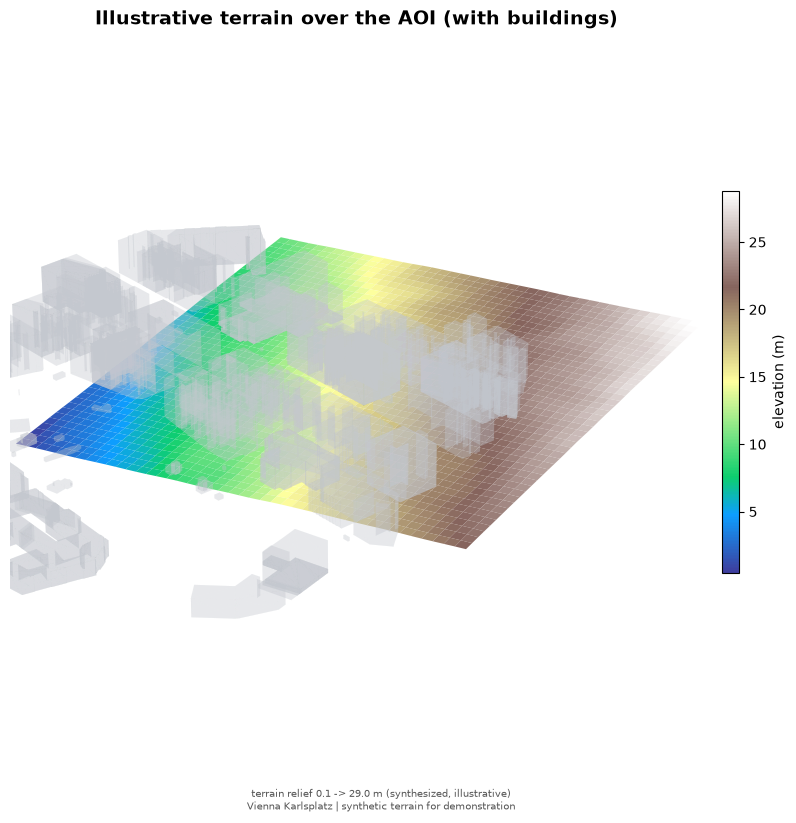

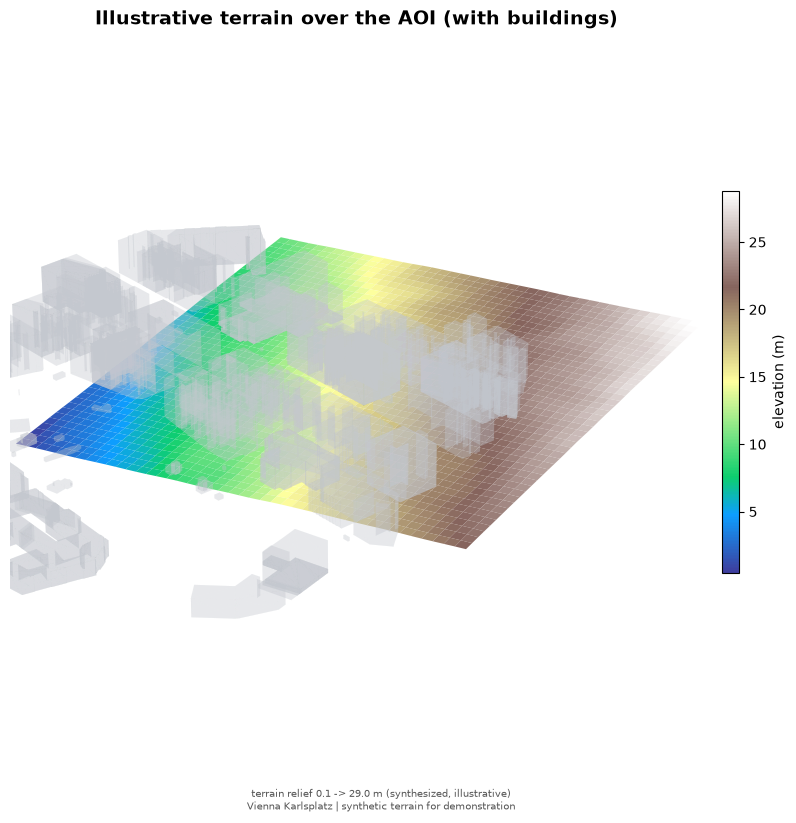

In [3]:
import ir_terrain

terrain_mesh, heights = ir_terrain.generate_terrain(
    size_m=512.0, n=44, slope=(0.035, 0.02), bumps=((2.5, 6.0), (1.5, 3.5))
)
print("terrain triangles:", len(terrain_mesh["terrain0"]["indices"]) // 3)
print("relief: %.1f -> %.1f m" % (float(heights.min()), float(heights.max())))

fig, ax = ir.terrain_3d(
    heights,
    size_m=512.0,
    context_faces=ia.building_faces(buildings),
    title="Illustrative terrain over the AOI (with buildings)",
    note="Vienna Karlsplatz | synthetic terrain for demonstration",
)
fig

## Baseline (flat) vs terrain-draped solar radiation grid

Run solar radiation twice: once flat (no `ground-geometry`), once with the
terrain as the drape target. On the grid path the result is the standard
512x512 `output`, but draped onto the relief - so sun-facing slopes gain
irradiance and shaded slopes lose it.

In [4]:
from infrared_sdk.analyses.types import (
    SolarRadiationModelRequest,
    BaseAnalysisPayload,
    AnalysesName,
)

tp = TimePeriod(
    start_month=7, start_day=15, start_hour=9, end_month=7, end_day=15, end_hour=17
)
loc = Location(latitude=ia.VIENNA_LAT, longitude=ia.VIENNA_LON)
wp = client.weather.filter_weather_data(identifier=weather_id, time_period=tp)


def sr_body():
    b = SolarRadiationModelRequest.from_weatherfile_payload(
        BaseAnalysisPayload(analysis_type=AnalysesName.solar_radiation), loc, tp, wp
    ).to_dict()
    b["latitude"] = ia.VIENNA_LAT
    b["longitude"] = ia.VIENNA_LON
    b["geometries"] = buildings
    return b


flat_res, _ = ia.run_job("solar-radiation", sr_body(), label="flat")
flat = np.array(flat_res["output"], dtype=float)

body = sr_body()
body["ground-geometry"] = terrain_mesh
terr_res, _ = ia.run_job("solar-radiation", body, label="terrain-drape")
terr = np.array(terr_res["output"], dtype=float)
print(
    "flat mean %.1f | terrain mean %.1f kWh/m2"
    % (float(np.nanmean(flat)), float(np.nanmean(terr)))
)

[solar-radiation/flat] Succeeded in 1.4s  keys=['max-legend', 'min-legend', 'output']


[solar-radiation/terrain-drape] Succeeded in 1.6s  keys=['max-legend', 'min-legend', 'output']
flat mean 4.4 | terrain mean 3.8 kWh/m2


### Result payload, described

`ground-geometry`-only runs return the **standard grid** shape (terrain drape):

```json
{ "output": [[...512...], ...], "min-legend": <num>, "max-legend": <num> }
```

So you read it exactly like the flat grid - the difference is that each cell's
irradiance now reflects the terrain orientation under it. (On a sensor /
facade run, `ground-geometry` acts as an occluder **and** culls **sub-grade
facade sensors** - cells whose sensor sits below the terrain surface are
dropped, so the `surfaces` payload keeps its shape but the per-surface
`sensor-count` falls where walls dip below the relief.)

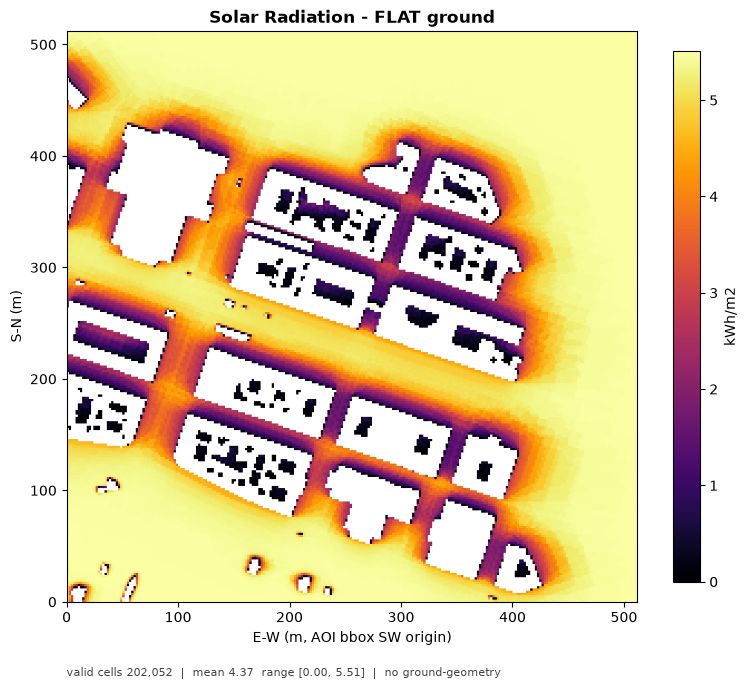

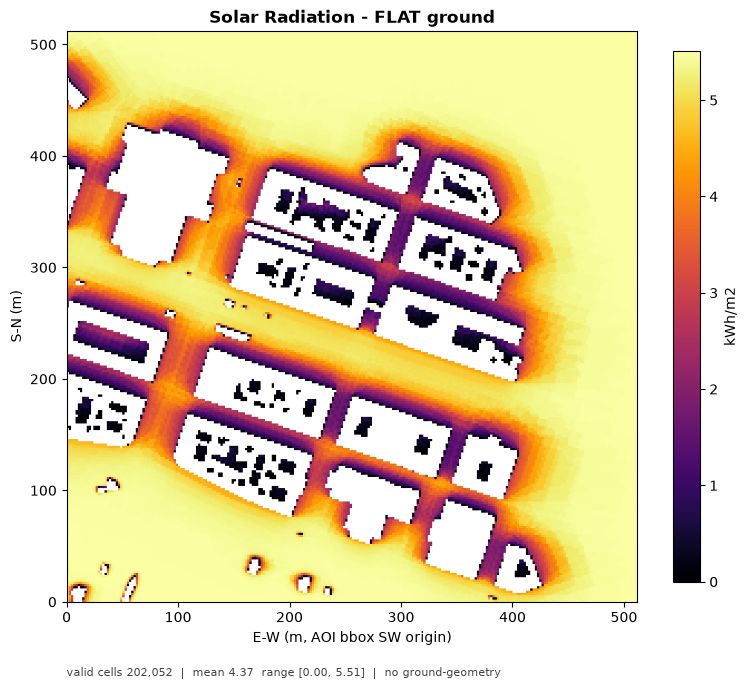

In [5]:
fig, ax = ir.grid_heatmap(
    flat,
    title="Solar Radiation - FLAT ground",
    cbar_label="kWh/m2",
    cmap="inferno",
    crop=True,
    note="no ground-geometry",
)
fig

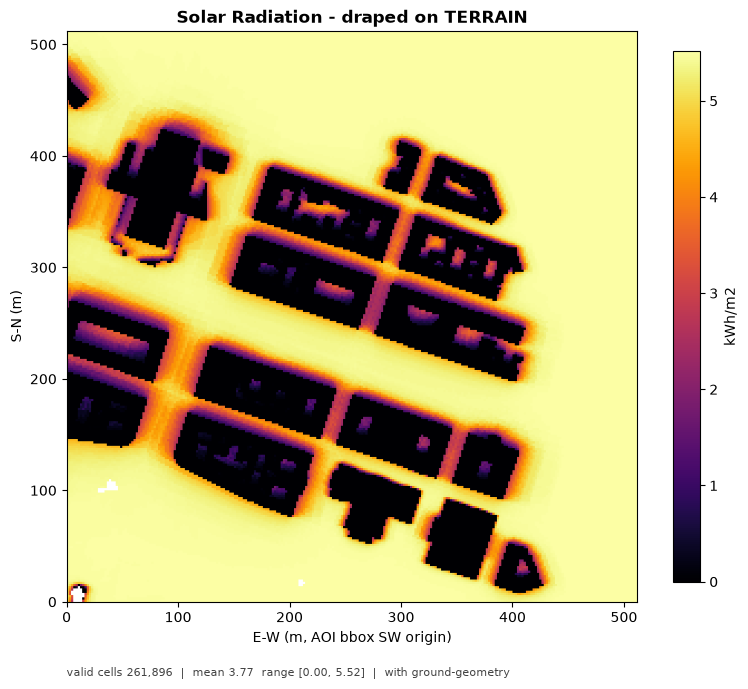

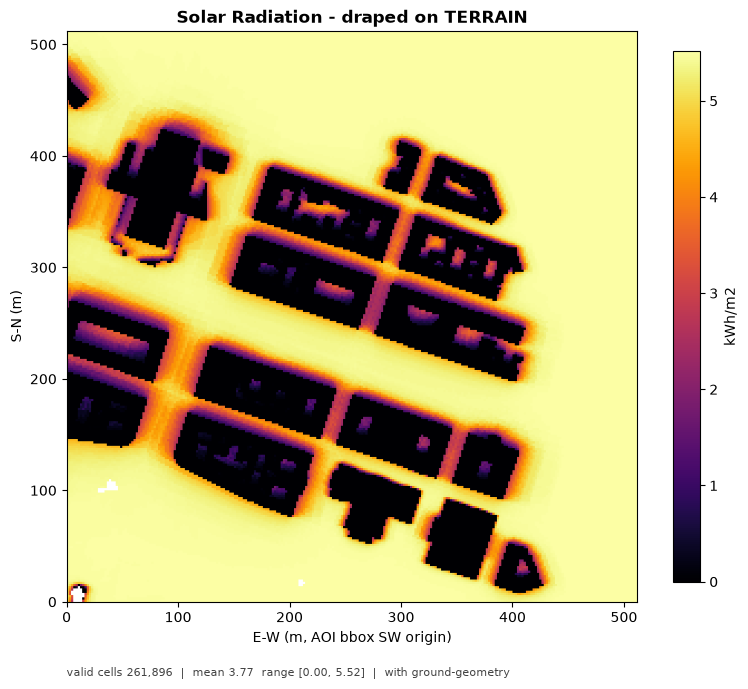

In [6]:
fig, ax = ir.grid_heatmap(
    terr,
    title="Solar Radiation - draped on TERRAIN",
    cbar_label="kWh/m2",
    cmap="inferno",
    crop=True,
    note="with ground-geometry",
)
fig

## The difference - how terrain reshapes the grid

Subtract the two grids on the cells they share. Tilting the ground toward the
sun **redistributes** irradiance: south / west-facing slopes pick up more,
flatter / north-facing cells gain less. (For this gentle synthetic relief the
net effect on the shared cells is a small overall **gain** - no cell drops below
the flat baseline; with steeper terrain you would also see self-shaded slopes
fall below zero delta. Cells the terrain drape adds or removes relative to the
flat mask are simply no-data on the other grid and are left out of the
subtraction.)

terrain - flat (shared cells):  mean +0.44 | max gain +5.50 | min 0.00 kWh/m2 (202052 cells)
no-data only on flat (terrain reveals ground): 0 | only on terrain: 59844


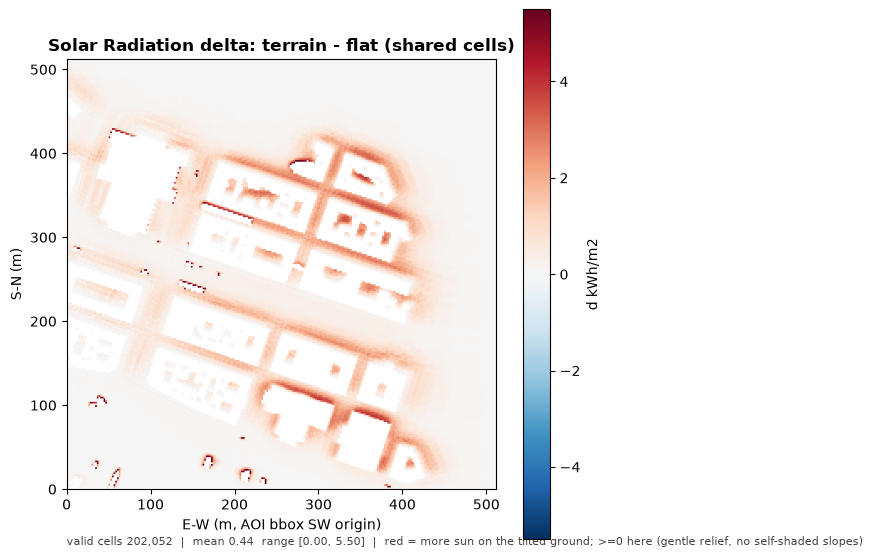

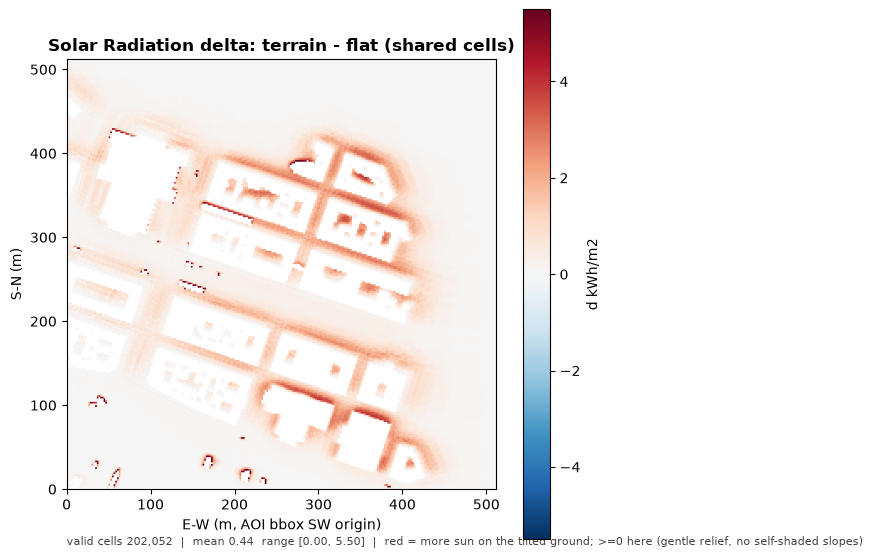

In [7]:
# Compare only where both grids have data; the rest is no-data on one side.
both = np.isfinite(flat) & np.isfinite(terr)
delta = np.where(both, terr - flat, np.nan)
d = delta[np.isfinite(delta)]
n_terr_only = int((np.isfinite(terr) & ~np.isfinite(flat)).sum())
n_flat_only = int((np.isfinite(flat) & ~np.isfinite(terr)).sum())
print(
    "terrain - flat (shared cells):  mean %+.2f | max gain %+.2f | min %.2f kWh/m2 (%d cells)"
    % (float(np.nanmean(d)), float(np.nanmax(d)), float(np.nanmin(d)), d.size)
)
print(
    "no-data only on flat (terrain reveals ground): %d | only on terrain: %d"
    % (n_flat_only, n_terr_only)
)
# Diverging scale centred at 0: red = terrain redistributes MORE sun here,
# blue would be less. For this relief the shared cells are gains (>= 0).
fig, ax = ir.grid_heatmap(
    delta,
    title="Solar Radiation delta: terrain - flat (shared cells)",
    cbar_label="d kWh/m2",
    cmap="RdBu_r",
    diverging=True,
    crop=True,
    note="red = more sun on the tilted ground; >=0 here (gentle relief, no self-shaded slopes)",
)
fig

## Summary

* `ground-geometry` **conforms the scene** (seats BYO buildings / trees onto
  the terrain), drapes the grid onto real relief, and occludes on sensor runs.
  It works on raytraced **and** thermal models.
* `terrain-alignment`: `auto-align` (default - seat misaligned objects) vs
  `assume-aligned` (validate-only → **422** if the scene is not pre-seated).
* On `analysis-surfaces` (facade / roof) runs, **sub-grade facade sensors are
  culled** (per-surface `sensor-count` drops where walls dip below the terrain).
* The SDK has no DEM fetch - bring your own terrain mesh (here synthesized).
  Match the tile-local meter frame of the buildings.
* Constraints: <= 500,000 triangles, >= 1 triangle (empty -> 422).